In [ ]:
import sys
import os
import time

sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt

from preprocessing.preprocess import preprocess
from models.KNN_optimized import KNNClassifier

from evaluation.metrics import (
    accuracy,
    precision,
    recall,
    f1_score,
    confusion_matrix
)

# KNN Binary Classification on MNIST

This notebook evaluates a manual KNN classifier using:
- Flatten features
- PCA features
- HOG features

## Flatten Feature Extraction

In this experiment, the MNIST images are represented using flattened pixel values.  
Each 28×28 image is converted into a 1D vector and passed to the KNN classifier.

The preprocessing function handles loading, normalization, binary label encoding, feature extraction, splitting into train/validation/test, and standardization.

In [65]:
X_tr_flat, X_val_flat, X_test_flat, y_tr_flat, y_val_flat, y_test_flat = preprocess(
    feature_method="flatten",
    binary=True,
    positive_class=1
)

 Starting Preprocessing Pipeline...
   Feature method : flatten
   Mode           : Binary

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Labels encoded — Positive class: Digit 1
   Training — Positive samples : 6742
   Training — Negative samples : 53258
   Test     — Positive samples : 1135
   Test     — Negative samples : 8865

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using FLATTEN...
 Images flattened successfully!
   Training shape : (60000, 784)
   Test shape     : (10000, 784)

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfully!
   Training mean (should be ~0) : 0.0000
   Training std  (should be ~1) : 0.9536

 Preprocessing Pipeline Complete!
   X_tr   :

In [66]:
knn_flat = KNNClassifier(k=1, batch_size=500)

knn_flat.fit(X_tr_flat, y_tr_flat)

In [67]:
y_val_pred_flat = knn_flat.predict(X_val_flat)

print("Validation Accuracy:", accuracy(y_val_flat, y_val_pred_flat))
print("Precision:", precision(y_val_flat, y_val_pred_flat))
print("Recall:", recall(y_val_flat, y_val_pred_flat))
print("F1-score:", f1_score(y_val_flat, y_val_pred_flat))

val_cm_flat = confusion_matrix(y_val_flat, y_val_pred_flat)

print(val_cm_flat)

Validation Accuracy: 0.9950833333333333
Precision: 0.9667405764966741
Recall: 0.989409984871407
F1-score: 0.9779439252336449
[[10633    45]
 [   14  1308]]


In [68]:
y_test_pred_flat = knn_flat.predict(X_test_flat)

print("Test Accuracy:", accuracy(y_test_flat, y_test_pred_flat))
print("Precision:", precision(y_test_flat, y_test_pred_flat))
print("Recall:", recall(y_test_flat, y_test_pred_flat))
print("F1-score:", f1_score(y_test_flat, y_test_pred_flat))

test_cm_flat = confusion_matrix(y_test_flat, y_test_pred_flat)

print(test_cm_flat)

Test Accuracy: 0.9943
Precision: 0.959114139693356
Recall: 0.9920704845814978
F1-score: 0.9753139887397141
[[8817   48]
 [   9 1126]]


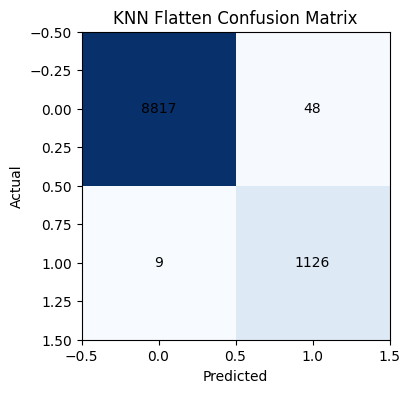

In [69]:
plt.figure(figsize=(5,4))

plt.imshow(test_cm_flat, cmap="Blues")

for i in range(2):
    for j in range(2):
        plt.text(j, i, test_cm_flat[i,j],
                 ha='center',
                 va='center')

plt.title("KNN Flatten Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("../results/knn_flatten_confusion_matrix.png")

plt.show()

In [70]:
with open("../results/knn_flatten_results.txt", "w") as f:

    f.write("KNN Flatten Results\n")
    f.write("=" * 40 + "\n\n")

    f.write(f"Accuracy : {accuracy(y_test_flat, y_test_pred_flat):.4f}\n")
    f.write(f"Precision: {precision(y_test_flat, y_test_pred_flat):.4f}\n")
    f.write(f"Recall   : {recall(y_test_flat, y_test_pred_flat):.4f}\n")
    f.write(f"F1-score : {f1_score(y_test_flat, y_test_pred_flat):.4f}\n\n")

    f.write("Confusion Matrix:\n")
    f.write(str(test_cm_flat))

print("Flatten results saved.")

Flatten results saved.


## PCA Feature Extraction

In this experiment, PCA is used to reduce the dimensionality of the image features.  
This helps reduce computation time for KNN while keeping the most important information from the images.

In [71]:
X_tr_pca, X_val_pca, X_test_pca, y_tr_pca, y_val_pca, y_test_pca = preprocess(
    feature_method="pca",
    binary=True,
    positive_class=1,
    pca_components=50
)

 Starting Preprocessing Pipeline...
   Feature method : pca
   Mode           : Binary

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Labels encoded — Positive class: Digit 1
   Training — Positive samples : 6742
   Training — Negative samples : 53258
   Test     — Positive samples : 1135
   Test     — Negative samples : 8865

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using PCA...
 Images flattened successfully!
   Training shape : (60000, 784)
   Test shape     : (10000, 784)
PCA applied successfully!
   Components kept    : 50
   Training shape     : (60000, 50)
   Test shape         : (10000, 50)
   Variance explained : 82.46%

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standar

## Model Training

The KNN classifier is created with the selected value of k = 1.  
During training, KNN stores the training samples and labels. It does not learn weights like Logistic Regression.

In [72]:
knn_pca = KNNClassifier(k=1, batch_size=500)

knn_pca.fit(X_tr_pca, y_tr_pca)

## Validation Evaluation

The validation set is used to evaluate the model before final testing.  
This helps check the model performance and compare feature extraction methods fairly.

In [73]:
y_val_pred_pca = knn_pca.predict(X_val_pca)

print("Validation Accuracy:", accuracy(y_val_pca, y_val_pred_pca))
print("Precision:", precision(y_val_pca, y_val_pred_pca))
print("Recall:", recall(y_val_pca, y_val_pred_pca))
print("F1-score:", f1_score(y_val_pca, y_val_pred_pca))

val_cm_pca = confusion_matrix(y_val_pca, y_val_pred_pca)

print(val_cm_pca)

Validation Accuracy: 0.9958333333333333
Precision: 0.9683357879234168
Recall: 0.9947049924357034
F1-score: 0.9813432835820894
[[10635    43]
 [    7  1315]]


## Final Test Evaluation

The test set is used only after validation to measure the final performance on unseen data.  
The reported metrics include accuracy, precision, recall, F1-score, and the confusion matrix.

In [74]:
y_test_pred_pca = knn_pca.predict(X_test_pca)

print("Test Accuracy:", accuracy(y_test_pca, y_test_pred_pca))
print("Precision:", precision(y_test_pca, y_test_pred_pca))
print("Recall:", recall(y_test_pca, y_test_pred_pca))
print("F1-score:", f1_score(y_test_pca, y_test_pred_pca))

test_cm_pca = confusion_matrix(y_test_pca, y_test_pred_pca)

print(test_cm_pca)

Test Accuracy: 0.9949
Precision: 0.9616695059625213
Recall: 0.9947136563876652
F1-score: 0.9779125162407969
[[8820   45]
 [   6 1129]]


## Confusion Matrix Visualization

The confusion matrix shows how many samples were correctly or incorrectly classified.  
It helps identify false positives and false negatives for digit 1 classification.

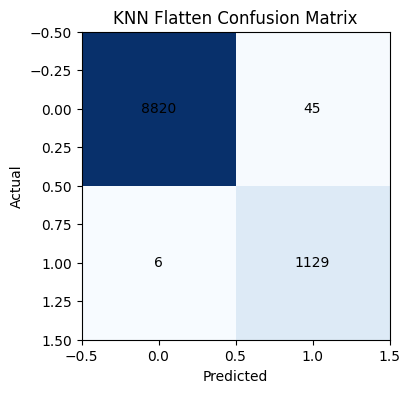

In [75]:
plt.figure(figsize=(5,4))

plt.imshow(test_cm_pca, cmap="Blues")

for i in range(2):
    for j in range(2):
        plt.text(j, i, test_cm_pca[i,j],
                 ha='center',
                 va='center')

plt.title("KNN Flatten Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("../results/knn_pca_confusion_matrix.png")

plt.show()

## Saving Results

The evaluation results and confusion matrix image are saved inside the results folder.  
These files will be used later in the report and model comparison.

In [76]:
with open("../results/knn_pca_results.txt", "w") as f:

    f.write("KNN PCA Results\n")
    f.write("=" * 40 + "\n\n")

    f.write(f"Accuracy : {accuracy(y_test_pca, y_test_pred_pca):.4f}\n")
    f.write(f"Precision: {precision(y_test_pca, y_test_pred_pca):.4f}\n")
    f.write(f"Recall   : {recall(y_test_pca, y_test_pred_pca):.4f}\n")
    f.write(f"F1-score : {f1_score(y_test_pca, y_test_pred_pca):.4f}\n\n")

    f.write("Confusion Matrix:\n")
    f.write(str(test_cm_pca))

print("PCA results saved.")

PCA results saved.


## HOG Feature Extraction

In this experiment, HOG features are used to describe the shape and edge structure of digits.  
This can help KNN focus on digit strokes rather than raw pixel intensity.

In [77]:
X_tr_hog, X_val_hog, X_test_hog, y_tr_hog, y_val_hog, y_test_hog = preprocess(
    feature_method="hog",
    binary=True,
    positive_class=1
)

 Starting Preprocessing Pipeline...
   Feature method : hog
   Mode           : Binary

 Loading data...
 MNIST Dataset Loaded Successfully!
   Training images  : (60000, 28, 28)
   Training labels  : (60000,)
   Test images      : (10000, 28, 28)
   Test labels      : (10000,)

  Encoding labels...
 Labels encoded — Positive class: Digit 1
   Training — Positive samples : 6742
   Training — Negative samples : 53258
   Test     — Positive samples : 1135
   Test     — Negative samples : 8865

 Normalizing pixels...
 Pixel values normalized to [0, 1]

 Extracting features using HOG...
 HOG features extracted successfully!
   Input shape  : (60000, 28, 28)
   Output shape : (60000, 441)
 HOG features extracted successfully!
   Input shape  : (10000, 28, 28)
   Output shape : (10000, 441)

  Splitting data...
 Train/Validation split done!
   Training   samples : 48000
   Validation samples : 12000

 Standardizing features...
 Features standardized successfully!
   Training mean (should be 

In [78]:
knn_hog = KNNClassifier(k=1, batch_size=500)

knn_hog.fit(X_tr_hog, y_tr_hog)

In [79]:
y_val_pred_hog = knn_hog.predict(X_val_hog)

print("Validation Accuracy:", accuracy(y_val_hog, y_val_pred_hog))
print("Precision:", precision(y_val_hog, y_val_pred_hog))
print("Recall:", recall(y_val_hog, y_val_pred_hog))
print("F1-score:", f1_score(y_val_hog, y_val_pred_hog))

val_cm_hog = confusion_matrix(y_val_hog, y_val_pred_hog)

print(val_cm_hog)

Validation Accuracy: 0.9905
Precision: 0.9308131241084165
Recall: 0.9871406959152799
F1-score: 0.9581497797356828
[[10581    97]
 [   17  1305]]


In [80]:
y_test_pred_hog = knn_hog.predict(X_test_hog)

print("Test Accuracy:", accuracy(y_test_hog, y_test_pred_hog))
print("Precision:", precision(y_test_hog, y_test_pred_hog))
print("Recall:", recall(y_test_hog, y_test_pred_hog))
print("F1-score:", f1_score(y_test_hog, y_test_pred_hog))

test_cm_hog = confusion_matrix(y_test_hog, y_test_pred_hog)

print(test_cm_hog)

Test Accuracy: 0.989
Precision: 0.9183673469387755
Recall: 0.9911894273127754
F1-score: 0.9533898305084746
[[8765  100]
 [  10 1125]]


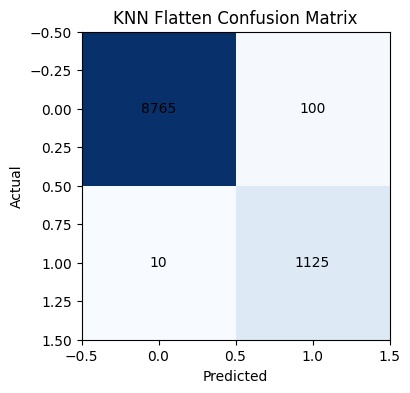

In [81]:
plt.figure(figsize=(5,4))

plt.imshow(test_cm_hog, cmap="Blues")

for i in range(2):
    for j in range(2):
        plt.text(j, i, test_cm_hog[i,j],
                 ha='center',
                 va='center')

plt.title("KNN Flatten Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("../results/knn_hog_confusion_matrix.png")

plt.show()

In [82]:
with open("../results/knn_hog_results.txt", "w") as f:

    f.write("KNN HOG Results\n")
    f.write("=" * 40 + "\n\n")

    f.write(f"Accuracy : {accuracy(y_test_hog, y_test_pred_hog):.4f}\n")
    f.write(f"Precision: {precision(y_test_hog, y_test_pred_hog):.4f}\n")
    f.write(f"Recall   : {recall(y_test_hog, y_test_pred_hog):.4f}\n")
    f.write(f"F1-score : {f1_score(y_test_hog, y_test_pred_hog):.4f}\n\n")

    f.write("Confusion Matrix:\n")
    f.write(str(test_cm_hog))

print("HOG results saved.")

HOG results saved.


# Feature Comparison

After evaluating the KNN classifier using Flatten, PCA, and HOG features, the final results are compared to determine which feature extraction method provides the best performance.

The comparison focuses on:
- Accuracy
- Precision
- Recall
- F1-score

This helps analyze the effect of feature engineering on KNN classification performance.

In [83]:
flatten_acc = accuracy(y_test_flat, y_test_pred_flat)
pca_acc = accuracy(y_test_pca, y_test_pred_pca)
hog_acc = accuracy(y_test_hog, y_test_pred_hog)

flatten_f1 = f1_score(y_test_flat, y_test_pred_flat)
pca_f1 = f1_score(y_test_pca, y_test_pred_pca)
hog_f1 = f1_score(y_test_hog, y_test_pred_hog)

print("=" * 60)
print("FINAL FEATURE COMPARISON")
print("=" * 60)

print("\n1) Flatten Features")
print("Accuracy :", flatten_acc)
print("F1-score :", flatten_f1)

print("\n2) PCA Features")
print("Accuracy :", pca_acc)
print("F1-score :", pca_f1)

print("\n3) HOG Features")
print("Accuracy :", hog_acc)
print("F1-score :", hog_f1)

FINAL FEATURE COMPARISON

1) Flatten Features
Accuracy : 0.9943
F1-score : 0.9753139887397141

2) PCA Features
Accuracy : 0.9949
F1-score : 0.9779125162407969

3) HOG Features
Accuracy : 0.989
F1-score : 0.9533898305084746
